<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/4_Taller_KNN_y_Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller KNN y Árboles de Decisión**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Talia Linares
- David Velandia

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

7 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.



### **Contexto del Caso**

Un banco portugués lo ha contratado como consultor de ciencia de datos. El banco tiene un problema de eficiencia: sus campañas de telemercadeo para ofrecer depósitos a plazo tienen una tasa de éxito muy baja. Se invierte mucho tiempo y recursos (costos de call center) llamando a clientes que no están interesados.

**Su misión:** Construir y optimizar modelos de Machine Learning que predigan qué clientes tienen mayor probabilidad de decir **"sí"** a la oferta (`y = 'yes'`).

El banco no solo quiere un modelo preciso, también quiere entender **POR QUÉ** un cliente es un buen prospecto. Su segundo objetivo es identificar cuáles son las **variables más relevantes** que usan los modelos para tomar sus decisiones. Esto permitirá al banco no solo enfocar sus llamadas, sino también crear mejores guiones de marketing y entender mejor a su clientela.

**El Dataset:** `bank-additional.csv` se encuentra en el repositorio del curso. Contiene información de más de 4.000 contactos de telemercadeo, incluyendo datos demográficos del cliente e información de la campaña (último contacto, resultado anterior).

**Para mayor información y descripción de las variables:** https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Preparación del Entorno y Datos

### 1.1. Carga de Librerías

Importe todas las librerías necesarias. Para problemas de clasificación se usa KNeighborsClassifier y DecisionTreeClassifier.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Mejorar visualización de dataframes y gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Carga y Exploración Inicial

In [3]:
df = pd.read_csv('bank-additional.csv', sep=';')

df.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          4119 non-null   int64 
 1   job          4119 non-null   object
 2   marital      4119 non-null   object
 3   education    4119 non-null   object
 4   default      4119 non-null   object
 5   housing      4119 non-null   object
 6   loan         4119 non-null   object
 7   contact      4119 non-null   object
 8   month        4119 non-null   object
 9   day_of_week  4119 non-null   object
 10  campaign     4119 non-null   int64 
 11  pdays        4119 non-null   int64 
 12  previous     4119 non-null   int64 
 13  poutcome     4119 non-null   object
 14  y            4119 non-null   object
dtypes: int64(4), object(11)
memory usage: 482.8+ KB


A partir de la salida de info() se observa que la base cuenta con 4 variables numéricas (int64) y 11 variables categóricas (object). Además, no existen valores nulos, ya que todas las columnas tienen 4119 registros no nulos. Esto simplifica el preprocesamiento porque no es necesario realizar imputación de datos faltantes.

Sin embargo, antes de entrenar los modelos sí es indispensable transformar las variables categóricas, debido a que algoritmos como KNN y Árboles de Decisión no trabajan directamente con texto. Para ello, se debe aplicar una codificación como OneHotEncoder, que convierte cada categoría en variables binarias. Por otro lado, las variables numéricas requieren escalamiento, especialmente en KNN, ya que este modelo se basa en distancias y podría verse afectado si una variable tiene una escala mucho mayor que las demás. En este caso, se utilizó StandardScaler para estandarizar las variables numéricas. Finalmente, dado que existen distintos tipos de variables en la misma base, resulta adecuado utilizar un ColumnTransformer junto con un Pipeline, de manera que el preprocesamiento quede integrado correctamente al entrenamiento del modelo.

In [5]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.89
yes,0.11


La variable objetivo presenta un desbalance importante, ya que aproximadamente el 89% de los registros pertenecen a la categoría “no”, mientras que solo el 11% corresponde a “yes”. Esto indica que la mayoría de los clientes contactados no adquirieron el producto ofrecido por el banco.

Este comportamiento tiene bastante lógica en un contexto real de campañas de marketing bancario, ya que normalmente solo una pequeña proporción de clientes termina aceptando una oferta financiera. En otras palabras, es esperable que existan muchos más rechazos que conversiones.

El principal problema de un dataset desbalanceado es que métricas como el accuracy pueden resultar engañosas. Por ejemplo, un modelo podría predecir siempre “no” y aun así obtener una exactitud cercana al 89%, aunque en realidad sería incapaz de identificar clientes potencialmente interesados. Por esta razón, en este tipo de problemas es más importante analizar métricas como el recall, el precision y el F1-score, especialmente para la clase minoritaria (“yes”), ya que estas permiten evaluar qué tan bien el modelo identifica a los clientes que realmente comprarían el producto.

## 2. Preprocesamiento (Usando Pipelines)

Vamos a definir nuestro `X` e `y`, y luego crear un `ColumnTransformer` que se encargue de aplicar `StandardScaler` a los números y `OneHotEncoder` a las categorías.

In [6]:
X = df.drop('y', axis=1)
y = df['y']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño Train: {X_train.shape}")
print(f"Tamaño Test: {X_test.shape}")

Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)


In [8]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X_train.select_dtypes(include=['object']).columns

print("Columnas Numéricas:")
print(numerical_features)
print("\nColumnas Categóricas:")
print(categorical_features)

Columnas Numéricas:
Index(['age', 'campaign', 'pdays', 'previous'], dtype='object')

Columnas Categóricas:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')


In [9]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 3. Modelo 1: KNN

Ahora uniremos el preprocesador y el clasificador KNN en un solo `Pipeline` y usaremos `GridSearchCV` para encontrar el mejor `k`.

In [10]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 11]
}

grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print(f"Mejor valor de 'k' para KNN: {grid_knn.best_params_}")
print(f"Mejor Recall-Macro: {grid_knn.best_score_:.4f}")

Mejor valor de 'k' para KNN: {'model__n_neighbors': 3}
Mejor Recall-Macro: 0.5922


## 4. Modelo 2: Árbol de Decisión

Repetiremos el proceso con un Árbol de Decisión. Esta vez, los hiperparámetros que ajustaremos serán `max_depth` (para evitar sobreajuste) y `min_samples_leaf`.

In [11]:
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [20, 50, 100]
}

grid_tree = GridSearchCV(
    tree_pipeline,
    param_grid_tree,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print(f"Mejores hiperparámetros para el Árbol: {grid_tree.best_params_}")
print(f"Mejor Recall-Macro: {grid_tree.best_score_:.4f}")

Mejores hiperparámetros para el Árbol: {'model__max_depth': 3, 'model__min_samples_leaf': 50}
Mejor Recall-Macro: 0.6013


## 5. Evaluación Final y Recomendación de Modelo

El Árbol de Decisión probablemente dio un mejor `recall-macro` (y es más rápido e interpretable). Vamos a declararlo nuestro **modelo ganador** y evaluarlo en el `test set` (nuestro examen final imparcial).

In [12]:
best_tree_model = grid_tree.best_estimator_

y_pred_tree = best_tree_model.predict(X_test)

print("--- Reporte de Clasificación Final (Árbol Optimizado) ---")

print(classification_report(y_test, y_pred_tree))

--- Reporte de Clasificación Final (Árbol Optimizado) ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.74      0.19      0.30        90

    accuracy                           0.90       824
   macro avg       0.82      0.59      0.62       824
weighted avg       0.89      0.90      0.88       824



El modelo obtuvo un accuracy general de 90%, lo que inicialmente parece un resultado bastante bueno. Sin embargo, al analizar las métricas por clase se observa que el desempeño no es igual para ambas categorías.

Para la clase “no”, el modelo tiene un recall de 0.99 y un precision de 0.91, lo que significa que identifica casi perfectamente a los clientes que no comprarán el producto. Esto ocurre en gran parte porque esa es la clase mayoritaria del dataset.

En cambio, para la clase “yes”, el precision fue de 0.74 y el recall de apenas 0.19. Esto significa que, de todos los clientes que el modelo predijo como posibles compradores, el 74% realmente sí compró el producto, por lo que el modelo es relativamente preciso cuando decide clasificar un caso como “yes”. Sin embargo, el recall tan bajo indica que solo logró identificar el 19% de todos los clientes que efectivamente compraron. En otras palabras, el modelo deja escapar muchas oportunidades potenciales.

Desde la perspectiva del banco, el recall suele ser especialmente importante, porque no identificar a un cliente interesado implica perder una posible venta. Aunque el modelo evita muchas falsas alarmas, sigue teniendo dificultades para detectar suficientes compradores reales, probablemente debido al desbalance de la base. Por eso, aunque el accuracy general sea alto, el desempeño sobre la clase minoritaria todavía puede considerarse limitado.

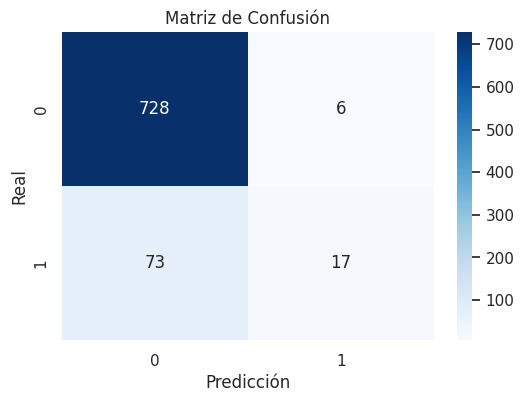

In [13]:
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')

plt.show()

## 6. ¿Cuáles son las Variables Más Relevantes?

Esta es la segunda parte de la solicitud del banco. Necesitamos explicar *por qué* el modelo toma sus decisiones.

### 6.1. Importancia de Variables (Árbol de Decisión)

In [14]:
final_tree_model = best_tree_model.named_steps['model']
final_preprocessor = best_tree_model.named_steps['preprocessor']


encoded_cat_features = final_preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([
    numerical_features,
    encoded_cat_features
])


importances = final_tree_model.feature_importances_


importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

importance_df.head(10)

,feature,importance
2,pdays,0.80
0,age,0.10
38,contact_telephone,0.06
3,previous,0.04
1,campaign,0.00
5,job_blue-collar,0.00
6,job_entrepreneur,0.00
7,job_housemaid,0.00
4,job_admin.,0.00
9,job_retired,0.00


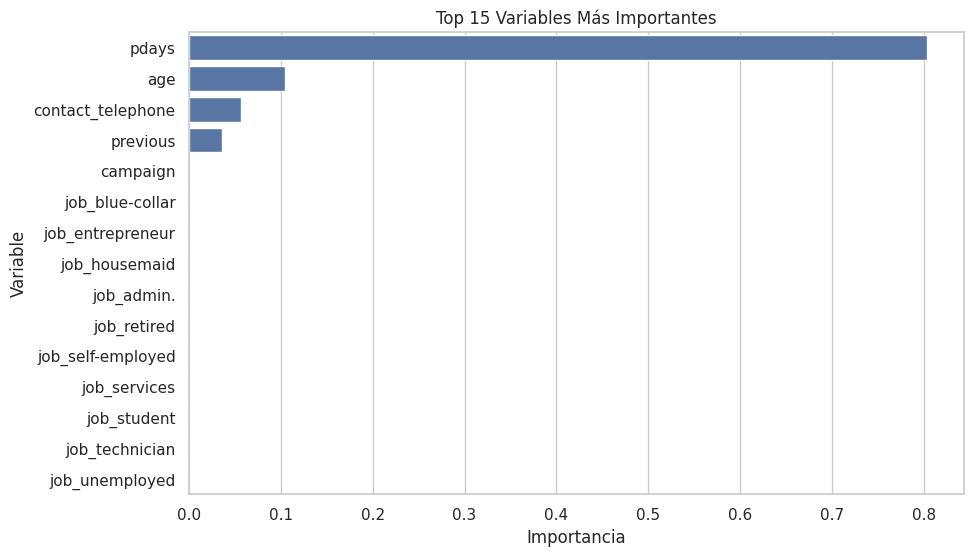

In [16]:
top15 = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x='importance',
    y='feature'
)

plt.title('Top 15 Variables Más Importantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.show()

## 7. Conclusión y Recomendación de Negocio

Es hora de traducir nuestros hallazgos en una recomendación de negocio clara.

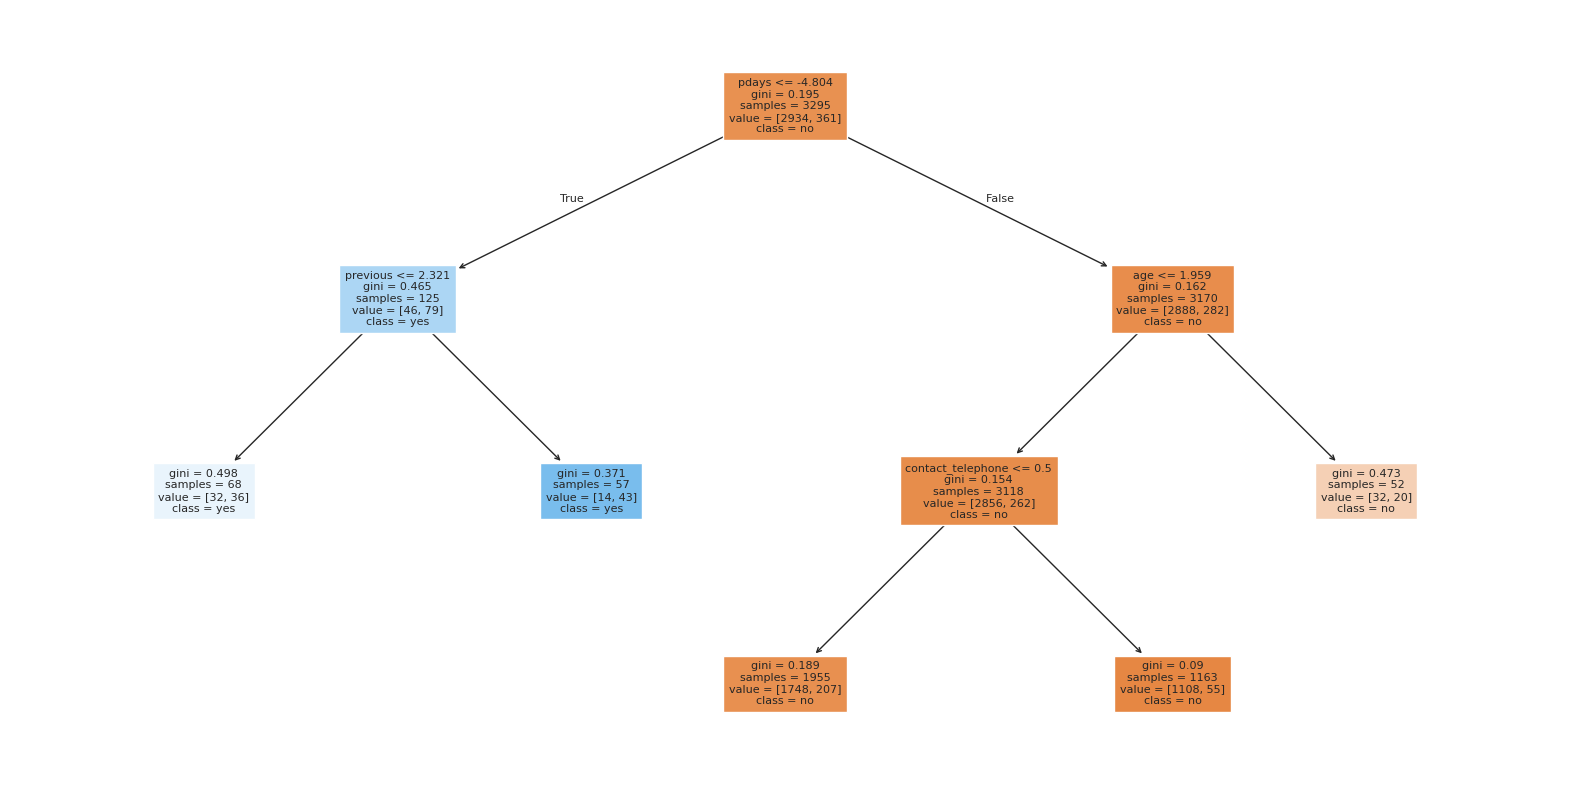

In [15]:
plt.figure(figsize=(20,10))

plot_tree(
    final_tree_model,
    feature_names=all_feature_names,
    class_names=['no', 'yes'],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

Con base en los resultados obtenidos, se recomienda utilizar el modelo de Árbol de Decisión, ya que además de presentar un desempeño adecuado, permite interpretar fácilmente las reglas de clasificación, algo especialmente valioso para el banco al momento de tomar decisiones comerciales. A diferencia de otros modelos más complejos, el árbol permite identificar claramente qué características influyen más en la probabilidad de compra de un cliente. Según el gráfico de importancia de variables, las variables más relevantes fueron pdays, age y contact_telephone, por lo que el banco debería prestar especial atención a la cantidad de días desde el último contacto, la edad del cliente y el tipo de contacto utilizado en campañas anteriores. Además, una de las reglas observadas en el árbol indica que cuando el cliente ha sido contactado recientemente (pdays bajo) y además ha tenido interacciones previas positivas (previous relativamente alto), la probabilidad de aceptar el producto aumenta considerablemente. En términos de negocio, esto sugiere que el banco debería priorizar clientes que ya hayan mostrado interés o interacción reciente, ya que son los que presentan mayor probabilidad de conversión.